In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 184 (delta 85), reused 139 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (184/184), 1.21 MiB | 4.85 MiB/s, done.
Resolving deltas: 100% (85/85), done.
/content/miniml


In [2]:
# %% [Cell 1] — Установка и импорты
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

from miniml.knn.knnclassifier import KNNClassifier

# Здесь предполагается, что класс KNNClassifier уже определен выше
np.random.seed(42)

In [3]:
# %% [Cell 2] — Подготовка данных
# 2D-синтетика для визуализации разделяющих поверхностей
X_synth, y_synth = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.0, random_state=42
)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_synth, y_synth, test_size=0.3, random_state=42)

# Реальные данные (Breast Cancer)
X_bc, y_bc = load_breast_cancer(return_X_y=True)
# KNN очень чувствителен к масштабу, обязательно стандартизируем
X_bc = StandardScaler().fit_transform(X_bc)

Xbc_train, Xbc_test, ybc_train, ybc_test = train_test_split(X_bc, y_bc, test_size=0.3, random_state=42)

In [4]:
# %% [Cell 3] — Базовая проверка (Uniform weights)
# Своя реализация
my_knn = KNNClassifier(neighbours=5, metric='euclid', weight_type='uniform')
my_knn.fit(Xbc_train, ybc_train)
my_acc = accuracy_score(ybc_test, my_knn.predict(Xbc_test))

# Sklearn реализация
sk_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
sk_knn.fit(Xbc_train, ybc_train)
sk_acc = accuracy_score(ybc_test, sk_knn.predict(Xbc_test))

print(f"Breast cancer — своя KNN (uniform):    {my_acc:.4f}")
print(f"Breast cancer — sklearn KNN (uniform): {sk_acc:.4f}")

Breast cancer — своя KNN (uniform):    0.9591
Breast cancer — sklearn KNN (uniform): 0.9591


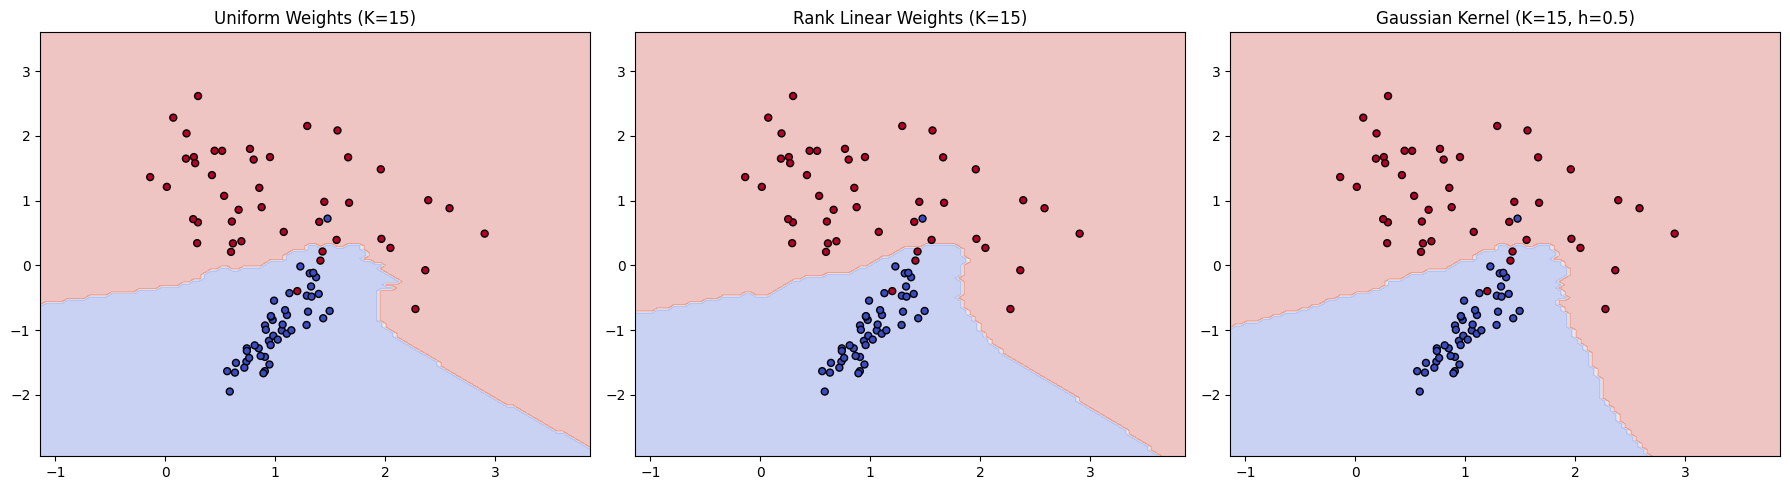

In [5]:
# %% [Cell 4] — Визуализация границ решений с разными весами
def plot_knn_boundary(model, X, y, ax, title):
    h_step = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h_step), np.arange(y_min, y_max, h_step))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Обычное голосование (Uniform)
knn_uni = KNNClassifier(neighbours=15, metric='euclid', weight_type='uniform')
knn_uni.fit(Xs_train, ys_train)
plot_knn_boundary(knn_uni, Xs_test, ys_test, axes[0], 'Uniform Weights (K=15)')

# 2. Ранговые веса
knn_rank = KNNClassifier(neighbours=15, metric='euclid', weight_type='rank_linear')
knn_rank.fit(Xs_train, ys_train)
plot_knn_boundary(knn_rank, Xs_test, ys_test, axes[1], 'Rank Linear Weights (K=15)')

# 3. Гауссовское ядро
knn_gauss = KNNClassifier(neighbours=15, metric='euclid', weight_type='kernel_gaussian', h=0.5)
knn_gauss.fit(Xs_train, ys_train)
plot_knn_boundary(knn_gauss, Xs_test, ys_test, axes[2], 'Gaussian Kernel (K=15, h=0.5)')

plt.tight_layout()
plt.show()

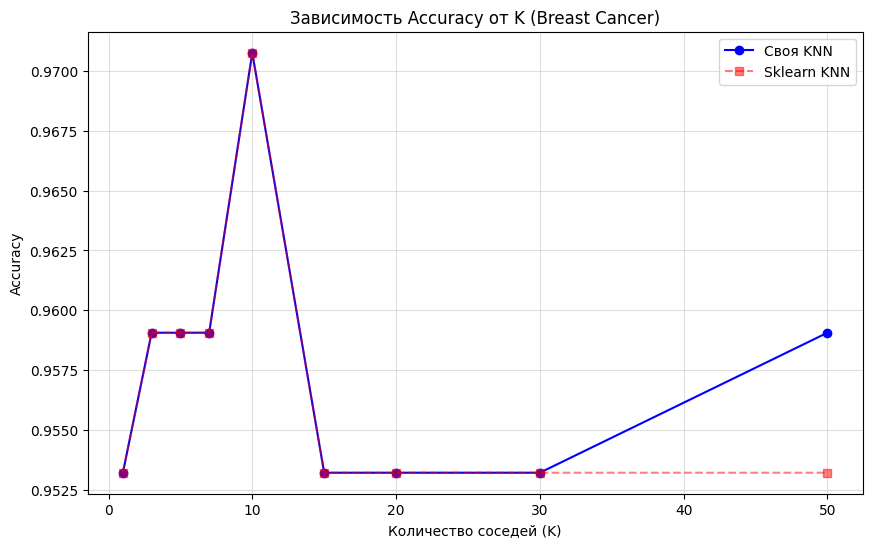

ИТОГ СРАВНЕНИЯ
 K  my_accuracy  sklearn_accuracy
 1     0.953216          0.953216
 3     0.959064          0.959064
 5     0.959064          0.959064
 7     0.959064          0.959064
10     0.970760          0.970760
15     0.953216          0.953216
20     0.953216          0.953216
30     0.953216          0.953216
50     0.959064          0.953216


In [6]:
# %% [Cell 5] — Влияние параметра K на Accuracy
k_values = [1, 3, 5, 7, 10, 15, 20, 30, 50]
my_accuracies = []
sk_accuracies = []

for k in k_values:
    # Своя реализация
    m = KNNClassifier(neighbours=k, metric='euclid', weight_type='uniform')
    m.fit(Xbc_train, ybc_train)
    my_accuracies.append(accuracy_score(ybc_test, m.predict(Xbc_test)))

    # Sklearn (для бейзлайна)
    sk = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform')
    sk.fit(Xbc_train, ybc_train)
    sk_accuracies.append(accuracy_score(ybc_test, sk.predict(Xbc_test)))

df_comp = pd.DataFrame({'K': k_values, 'my_accuracy': my_accuracies, 'sklearn_accuracy': sk_accuracies})

plt.figure(figsize=(10, 6))
plt.plot(df_comp['K'], df_comp['my_accuracy'], marker='o', label='Своя KNN', linestyle='-', color='b')
plt.plot(df_comp['K'], df_comp['sklearn_accuracy'], marker='s', label='Sklearn KNN', linestyle='--', color='r', alpha=0.5)

plt.xlabel('Количество соседей (K)')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от K (Breast Cancer)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print("=" * 45)
print("ИТОГ СРАВНЕНИЯ")
print("=" * 45)
print(df_comp.to_string(index=False))

In [7]:
# %% [Cell 6] — Тестирование различных типов взвешивания
weight_types = [
    'uniform',
    'rank_linear',
    'kernel_epanechnikov',
    'kernel_gaussian'
]
results = []

for w_type in weight_types:
    # Для ядер берем окно h побольше, так как данные отскалированы (std=1)
    m = KNNClassifier(neighbours=15, metric='euclid', weight_type=w_type, h=2.0)
    m.fit(Xbc_train, ybc_train)
    acc = accuracy_score(ybc_test, m.predict(Xbc_test))
    results.append((w_type, acc))

df_weights = pd.DataFrame(results, columns=['Схема взвешивания', 'Accuracy'])
print("Влияние схемы взвешивания (K=15):")
print("-" * 45)
print(df_weights.to_string(index=False))

Влияние схемы взвешивания (K=15):
---------------------------------------------
  Схема взвешивания  Accuracy
            uniform  0.953216
        rank_linear  0.970760
kernel_epanechnikov  0.953216
    kernel_gaussian  0.964912
